## *Kapitza Pendulum Numerical Assignment Alexander Umansky*

### Part 1: Simple Pendulum

In [1]:
#Impoering Libraries
import matplotlib.pyplot as plt
plt.style.use('default')
import numpy as np
plt.rcParams['figure.dpi'] = 100

In [2]:
#Defining Physical Constants
L = 1.00  #Length of rod (m)
m = 1.00  #Mass (kg)
g = 9.81  #Acceleration of gravity (m/s^2)
omega_0 = np.sqrt(g/L) #Harmonic frequency (1/s)
T_0 = 2*np.pi/omega_0 #Oscillation period (s)

In [3]:
def Simple_Pendulum(N = 500, theta_0 = 0.01):
    dt = (T_0/N)*10  #Timestep (s)
    theta = np.zeros(N)
    v = np.zeros(N)
    F = np.zeros(N)
    t = np.zeros(N)
    kinetic = np.zeros(N)
    potential = np.zeros(N)

    theta[0] = theta_0 #Initial angle (rad)
    v[0] = 0.0 #Initial angular velocity (rad/s)
    t[0] = 0.0 #Initial time (s)
    kinetic[0] = 0.5*m*(L*v[0])**2
    potential[0] = m*g*L*(1-np.cos(theta[0]))

    for i in range(0,N-1,1):
        F[i] = -omega_0**2*np.sin(theta[i])
        v2 = v[i] + F[i]*dt/2
        theta[i+1] = theta[i] + v2*dt
        F[i+1] = -omega_0**2*np.sin(theta[i+1])
        v[i+1] = v2 + F[i+1]*dt/2
        t[i+1] = t[i] + dt
        kinetic[i+1]=0.5*m*(L*v[i+1])**2
        potential[i+1]=m*g*L*(1-np.cos(theta[i+1]))
    return kinetic, potential, t

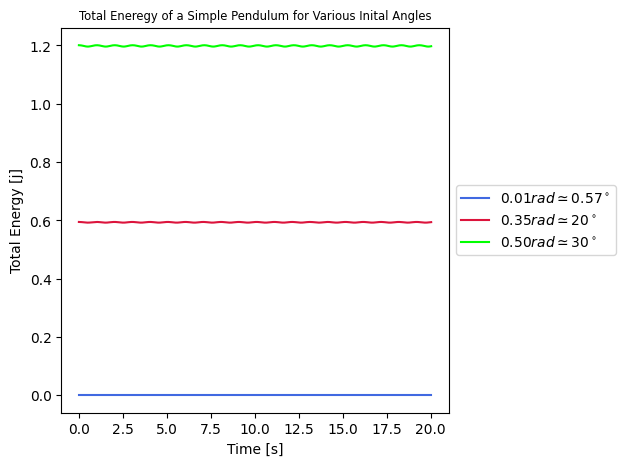

Average Kinetic and Potential Energy (respectively) for 20* init angle
0.29679566489262793 0.2968085814847305
Average Kinetic and Potential Energy (respectively) for $0.57* init angle
0.00024411982341763505 0.0002454085411100879


In [4]:
N = 500
set_kinetic = np.ones((3, N))
set_potential = np.ones((3, N))

kinetic, potential, t = Simple_Pendulum(theta_0 = 0.01)
set_kinetic[0] = kinetic
set_potential[0] = potential

kinetic, potential, t = Simple_Pendulum(theta_0 = 0.35)
set_kinetic[1] = kinetic
set_potential[1] = potential

kinetic, potential, t = Simple_Pendulum(theta_0 = 0.5)
set_kinetic[2] = kinetic
set_potential[2] = potential

plt.figure(figsize = (5, 5))
plt.plot(t, set_kinetic[0]+set_potential[0], color = 'royalblue', label = f"$0.01rad  \simeq  0.57^\circ $")
plt.plot(t, set_kinetic[1]+set_potential[1], color = 'crimson', label = f'$0.35rad \simeq 20^\circ $')
plt.plot(t, set_kinetic[2]+set_potential[2], color = 'lime', label = f'$0.50rad \simeq 30^\circ$')
plt.xlabel('Time [s]')
plt.ylabel('Total Energy [j]')
plt.title('Total Eneregy of a Simple Pendulum for Various Inital Angles', size = 'small')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

print(f'Average Kinetic and Potential Energy (respectively) for 20* init angle')
print(np.average(set_kinetic[1]), np.average(set_potential[1]))
print(f"Average Kinetic and Potential Energy (respectively) for $0.57* init angle")
print(np.average(set_kinetic[0]), np.average(set_potential[0]))

In [5]:
print("Relative Error for theta = 0.01 and N = 2000")
kinetic, potential, t = Simple_Pendulum(N = 2000)
print((np.max(kinetic + potential)-np.min(kinetic + potential)) / (kinetic[0]+potential[0])*100)

print("Relative Error for theta = 0.01 and N = 1000")
kinetic, potential, t = Simple_Pendulum(N = 1000)
print((np.max(kinetic + potential)-np.min(kinetic + potential)) / (kinetic[0]+potential[0])*100)

print("Relative Error for theta = 0.01 and N = 500")
kinetic, potential, t = Simple_Pendulum(N = 500)
print((np.max(kinetic + potential)-np.min(kinetic + potential)) / (kinetic[0]+potential[0])*100)

Relative Error for theta = 0.01 and N = 2000
0.024673805277944025
Relative Error for theta = 0.01 and N = 1000
0.0986952154191478
Relative Error for theta = 0.01 and N = 500
0.3945743073663582


*Comment to part 1:*
By increasing the starting angle we increase the total energy of the pendulum. 
The average values of kinetic and potential energy become more smilar as initial angle goes to 0. This can also be seen graphically as the total for larger angle has nopticably more variation in value in comparison to those for lower angles. 
Relative error decreases as we decreas dt or increase N. 0.1% mark is crossed when N is approximately 1000.

### Part 2

In [6]:
def Pendulum_HO(N = 500, c = 10, theta_0 = 0.01, amp = 0.05*L, gamma = 0.2*omega_0):
    dt = (T_0/N)*c  #Timestep (s)
    theta = np.zeros(N)
    v = np.zeros(N)
    F = np.zeros(N)
    t = np.zeros(N)
    kinetic = np.zeros(N)
    potential = np.zeros(N)

    theta[0] = theta_0 #Initial angle (rad)
    v[0] = 0.0 #Initial angular velocity (rad/s)
    t[0] = 0.0 #Initial time (s)
    kinetic[0] = 0.5*m*(L*v[0])**2
    potential[0] = m*g*L*(1-np.cos(theta[0]))

    for i in range(0,N-1,1):
        F[i] = -omega_0**2*np.sin(theta[i]) + (amp*gamma**2)*np.cos(gamma*t[i])*np.cos(theta[i])/L
        v2 = v[i] + F[i]*dt/2
        theta[i+1] = theta[i] + v2*dt
        t[i+1] = t[i] + dt
        F[i+1] = -omega_0**2*np.sin(theta[i+1]) + (amp*gamma**2)*np.cos(gamma*t[i+1])*np.cos(theta[i+1])/L
        v[i+1] = v2 + F[i+1]*dt/2
        kinetic[i+1]=0.5*m*(L*v[i+1])**2
        potential[i+1]=m*g*L*(1-np.cos(theta[i+1]))
    return theta, v, t, kinetic+potential

Text(0.5, 1.0, 'Horizontal Kapitza Pendulum: Angular Velocity - Time Plot for N = 1000')

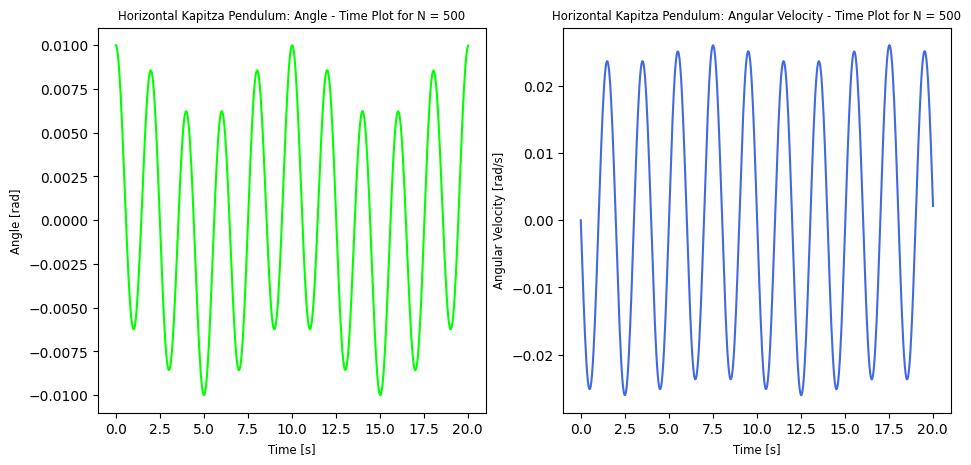

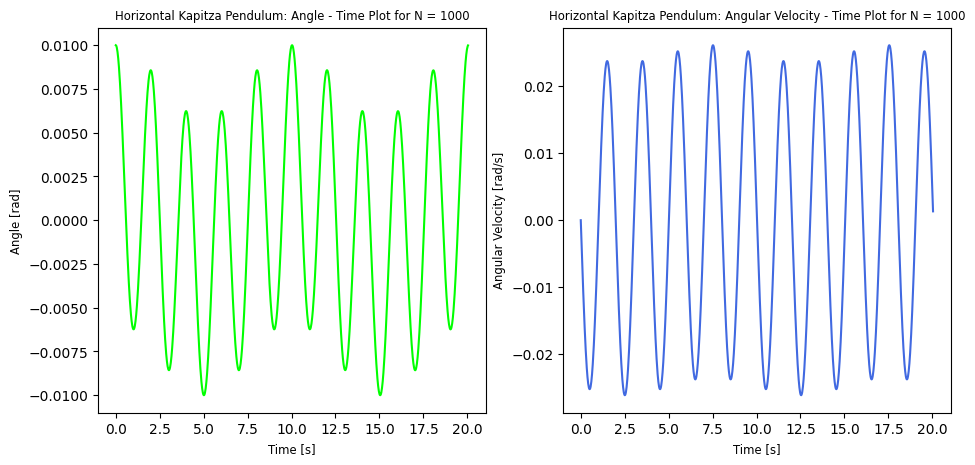

In [7]:
theta_a, v_a, t_a, E = Pendulum_HO()
theta_b, v_b, t_b, E = Pendulum_HO(N = 1000)

fig_2_a, (ax1, ax2) = plt.subplots(1,2, figsize=(11,5))
ax1.plot(t_a, theta_a, color = 'lime')
ax2.plot(t_a, v_a, color = 'royalblue')
ax1.set_xlabel('Time [s]', size = 'small')
ax1.set_ylabel('Angle [rad]', size = 'small')
ax2.set_xlabel('Time [s]', size = 'small')
ax2.set_ylabel('Angular Velocity [rad/s]', size = 'small')
ax1.set_title('Horizontal Kapitza Pendulum: Angle - Time Plot for N = 500', size = 'small')
ax2.set_title('Horizontal Kapitza Pendulum: Angular Velocity - Time Plot for N = 500', size = 'small')

fig_2_b, (ax3, ax4) = plt.subplots(1,2, figsize=(11,5))
ax3.plot(t_b, theta_b, color = 'lime')
ax4.plot(t_b, v_b, color = 'royalblue')
ax3.set_xlabel('Time [s]', size = 'small')
ax3.set_ylabel('Angle [rad]', size = 'small')
ax4.set_xlabel('Time [s]', size = 'small')
ax4.set_ylabel('Angular Velocity [rad/s]', size = 'small')
ax3.set_title('Horizontal Kapitza Pendulum: Angle - Time Plot for N = 1000', size = 'small')
ax4.set_title('Horizontal Kapitza Pendulum: Angular Velocity - Time Plot for N = 1000', size = 'small')

In [8]:
def Pendulum_VO(N = 500, theta_0 = 0.01, c = 10, amp = 0.05*L, gamma = 0.2*omega_0):
    dt = (T_0/N)*c  #Timestep (s)
    theta = np.zeros(N)
    v = np.zeros(N)
    F = np.zeros(N)
    t = np.zeros(N)
    kinetic = np.zeros(N)
    potential = np.zeros(N)

    theta[0] = theta_0 #Initial angle (rad)
    v[0] = 0.0 #Initial angular velocity (rad/s)
    t[0] = 0.0 #Initial time (s)
    kinetic[0] = 0.5*m*(L*v[0])**2
    potential[0] = m*g*L*(1-np.cos(theta[0]))

    for i in range(0,N-1,1):
        F[i] = -omega_0**2*np.sin(theta[i]) + (amp*gamma**2)*np.cos(gamma*t[i])*np.sin(theta[i])/L
        v2 = v[i] + F[i]*dt/2
        theta[i+1] = theta[i] + v2*dt
        t[i+1] = t[i] + dt
        F[i+1] = -omega_0**2*np.sin(theta[i+1]) + (amp*gamma**2)*np.cos(gamma*t[i+1])*np.sin(theta[i+1])/L
        v[i+1] = v2 + F[i+1]*dt/2
        kinetic[i+1]=0.5*m*(L*v[i+1])**2
        potential[i+1]=m*g*L*(1-np.cos(theta[i+1]))
    return theta, v, t, kinetic+potential

Text(0.5, 1.0, 'Vertical Kapitza Pendulum: Angular Velocity - Time Plot for N = 500')

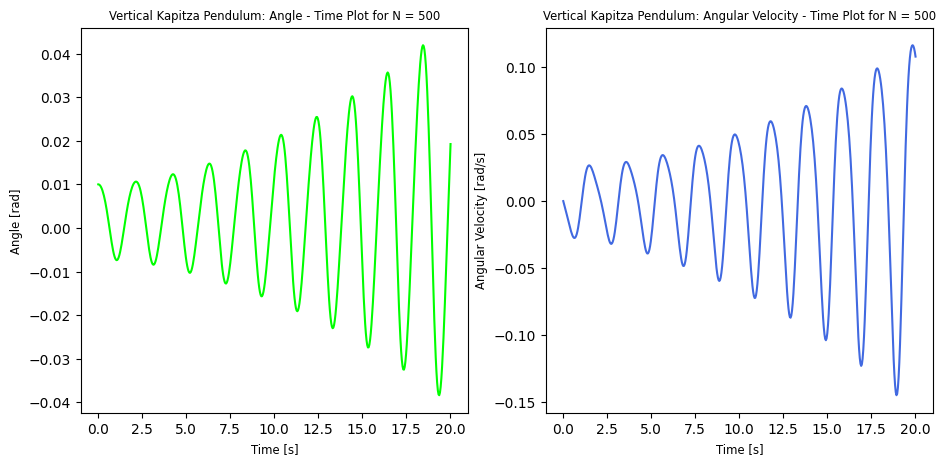

In [9]:
theta, v, t, E = Pendulum_VO(amp = 0.5*L, gamma = omega_0)

fig_2_c, (ax1, ax2) = plt.subplots(1,2, figsize=(11,5))
ax1.plot(t, theta, color = 'lime')
ax2.plot(t, v, color = 'royalblue')
ax1.set_xlabel('Time [s]', size = 'small')
ax1.set_ylabel('Angle [rad]', size = 'small')
ax2.set_xlabel('Time [s]', size = 'small')
ax2.set_ylabel('Angular Velocity [rad/s]', size = 'small')
ax1.set_title('Vertical Kapitza Pendulum: Angle - Time Plot for N = 500', size = 'small')
ax2.set_title('Vertical Kapitza Pendulum: Angular Velocity - Time Plot for N = 500', size = 'small')

### Part 3

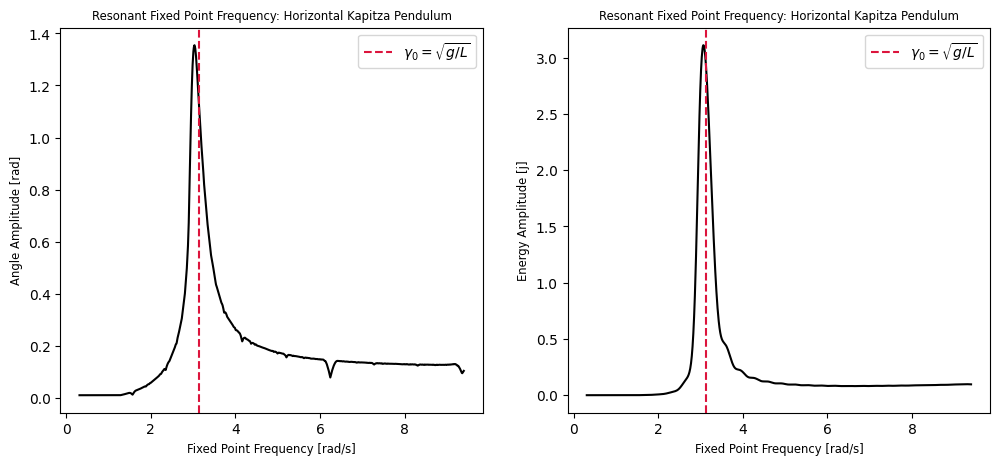

In [10]:
gamma_vals = np.linspace(0.1, 3, 1000)*omega_0
e_av = np.zeros(1000)
angle_amp_av = np.zeros(1000)
i = 0
for gamma_i in gamma_vals:
    theta, v, t, E = Pendulum_HO(gamma = gamma_i)
    angle_amp_av[i] = np.max(theta)
    e_av[i] = np.average(E)
    i += 1

fig_3_a, (ax1, ax2) = plt.subplots(1,2, figsize=(12,5))
ax1.plot(gamma_vals, angle_amp_av, color = 'black')
ax2.plot(gamma_vals, e_av, color = 'black')
ax1.axvline(omega_0, ls = '--', color = 'crimson', label = '$\gamma_{0} = \sqrt{g/L} $')
ax2.axvline(omega_0, ls = '--', color = 'crimson', label = '$\gamma_{0} = \sqrt{g/L} $')


ax1.set_xlabel('Fixed Point Frequency [rad/s]', size = 'small')
ax1.set_ylabel('Angle Amplitude [rad]', size = 'small')
ax2.set_xlabel('Fixed Point Frequency [rad/s]', size = 'small')
ax2.set_ylabel('Energy Amplitude [j]', size = 'small')
ax1.set_title('Resonant Fixed Point Frequency: Horizontal Kapitza Pendulum', size = 'small')
ax2.set_title('Resonant Fixed Point Frequency: Horizontal Kapitza Pendulum', size = 'small')
ax1.legend()
ax2.legend()

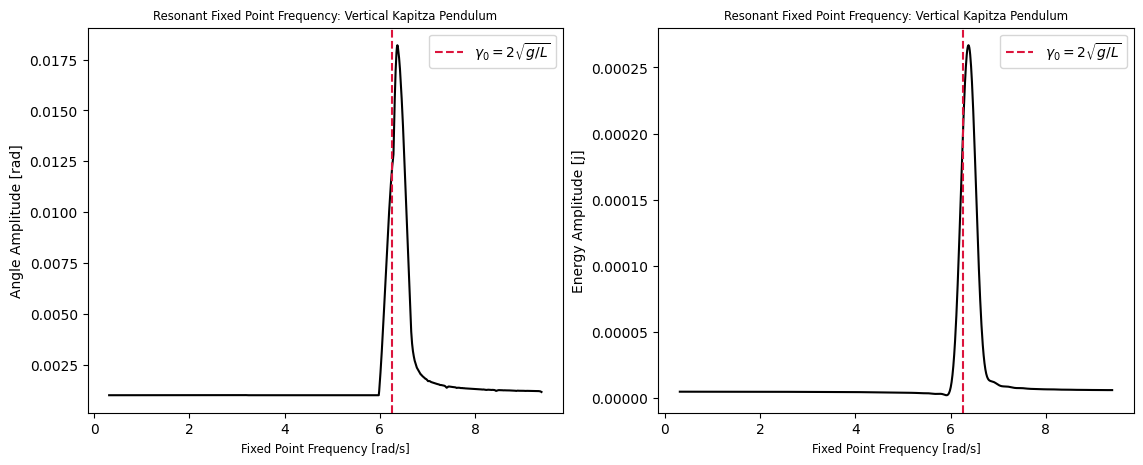

In [11]:
gamma_vals = np.linspace(0.1, 3, 1000)*omega_0
e_av = np.zeros(1000)
angle_amp_av = np.zeros(1000)
i = 0
for gamma_i in gamma_vals:
    theta, v, t, E = Pendulum_VO(theta_0= 0.001, gamma = gamma_i)
    angle_amp_av[i] = np.max(theta)
    e_av[i] = np.average(E)
    i += 1

fig_3_b, (ax1, ax2) = plt.subplots(1,2, figsize=(13.5,5))
ax1.plot(gamma_vals, angle_amp_av, color = 'black')
ax2.plot(gamma_vals, e_av, color = 'black')
ax1.axvline(2*omega_0, ls = '--', color = 'crimson', label = '$\gamma_{0} = 2\sqrt{g/L} $')
ax2.axvline(2*omega_0, ls = '--', color = 'crimson', label = '$\gamma_{0} = 2\sqrt{g/L} $')

ax1.set_xlabel('Fixed Point Frequency [rad/s]', size = 'small')
ax1.set_ylabel('Angle Amplitude [rad]')
ax2.set_xlabel('Fixed Point Frequency [rad/s]', size = 'small')
ax2.set_ylabel('Energy Amplitude [j]')
ax1.set_title('Resonant Fixed Point Frequency: Vertical Kapitza Pendulum', size = 'small')
ax2.set_title('Resonant Fixed Point Frequency: Vertical Kapitza Pendulum', size = 'small')
ax1.legend()
ax2.legend()

### Part 4

plot theta for theta_0, gamma and HO/VO

<function matplotlib.pyplot.show(close=None, block=None)>

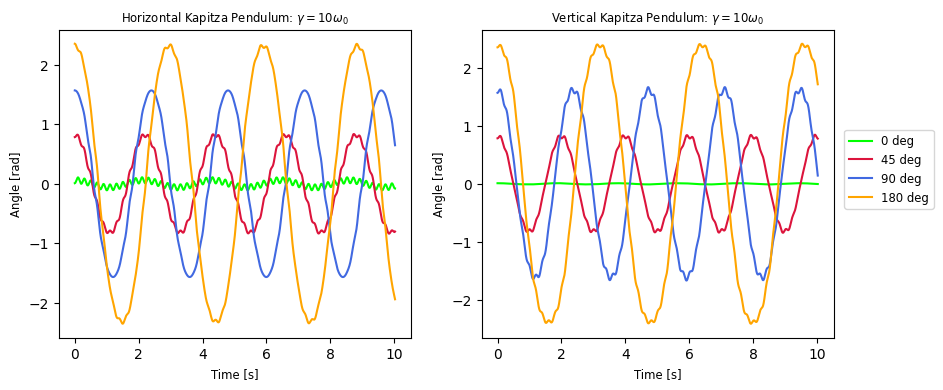

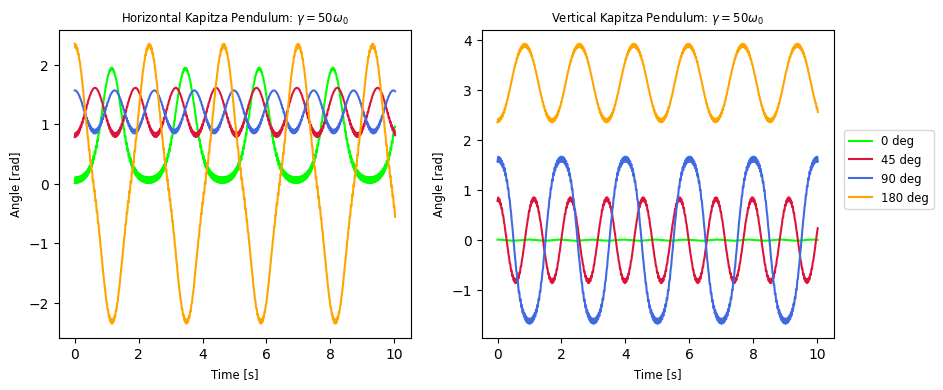

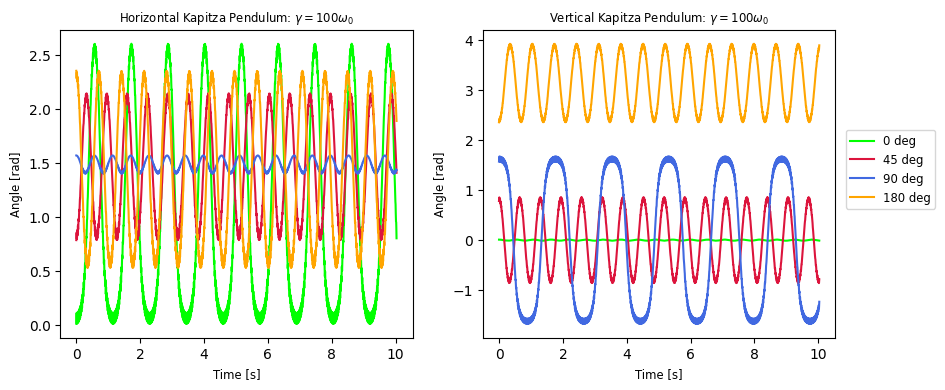

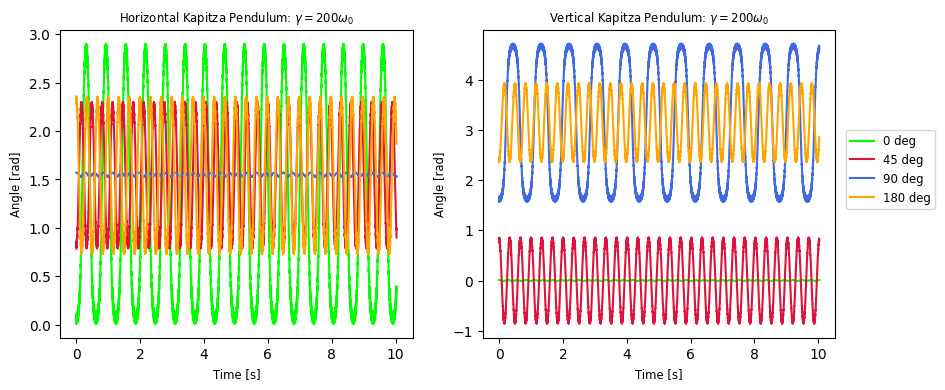

In [20]:
angle_arr = np.array([0.01, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
theta_set = np.zeros(((2, 5, 20000)))

i = 0
for angle in angle_arr:
    theta_h, v, t, E = Pendulum_HO(N = 20000, theta_0 = angle, c = 5, gamma = 10*omega_0)
    theta_v, v, t, E = Pendulum_VO(N = 20000, theta_0 = angle, c = 5, gamma = 10*omega_0)
    theta_set[0][i] = theta_h
    theta_set[1][i] = theta_v
    i += 1

fig_4_a, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.plot(t, theta_set[0][0], color = 'lime', label = '0 deg')
ax1.plot(t, theta_set[0][1], color = 'crimson', label = '45 deg')
ax1.plot(t, theta_set[0][2], color = 'royalblue', label = '90 deg')
ax1.plot(t, theta_set[0][3], color = 'orange', label = '180 deg')
ax2.plot(t, theta_set[1][0], color = 'lime', label = '0 deg')
ax2.plot(t, theta_set[1][1], color = 'crimson', label = '45 deg')
ax2.plot(t, theta_set[1][2], color = 'royalblue', label = '90 deg')
ax2.plot(t, theta_set[1][3], color = 'orange',label = '180 deg')
ax1.set_title('Horizontal Kapitza Pendulum: $\gamma = 10\omega_{0}$', size = 'small')
ax2.set_title('Vertical Kapitza Pendulum: $\gamma = 10\omega_{0}$', size = 'small')
ax1.set_xlabel('Time [s]', size = 'small')
ax2.set_xlabel('Time [s]',size = 'small')
ax1.set_ylabel('Angle [rad]',size = 'small')
ax2.set_ylabel('Angle [rad]', size = 'small')
#ax1.legend(loc='lower right', fontsize='small')
ax2.legend(loc='lower right', bbox_to_anchor=(1.3, 0.4), fontsize='small')


i = 0
for angle in angle_arr:
    theta_h, v, t, E = Pendulum_HO(N = 20000, theta_0 = angle, c = 5, gamma = 50*omega_0)
    theta_v, v, t, E = Pendulum_VO(N = 20000, theta_0 = angle, c = 5, gamma = 50*omega_0)
    theta_set[0][i] = theta_h
    theta_set[1][i] = theta_v
    i += 1

fig_4_b, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.plot(t, theta_set[0][0], color = 'lime', label = '0 deg')
ax1.plot(t, theta_set[0][1], color = 'crimson', label = '45 deg')
ax1.plot(t, theta_set[0][2], color = 'royalblue', label = '90 deg')
ax1.plot(t, theta_set[0][3], color = 'orange', label = '180 deg')
ax2.plot(t, theta_set[1][0], color = 'lime', label = '0 deg')
ax2.plot(t, theta_set[1][1], color = 'crimson', label = '45 deg')
ax2.plot(t, theta_set[1][2], color = 'royalblue', label = '90 deg')
ax2.plot(t, theta_set[1][3], color = 'orange',label = '180 deg')
ax1.set_title('Horizontal Kapitza Pendulum: $\gamma = 50\omega_{0}$', size = 'small')
ax2.set_title('Vertical Kapitza Pendulum: $\gamma = 50\omega_{0}$', size = 'small')
ax1.set_xlabel('Time [s]', size = 'small')
ax2.set_xlabel('Time [s]',size = 'small')
ax1.set_ylabel('Angle [rad]',size = 'small')
ax2.set_ylabel('Angle [rad]', size = 'small')
#ax1.legend(loc='lower right', fontsize='small')
ax2.legend(loc='lower right', bbox_to_anchor=(1.3, 0.4), fontsize='small')


i = 0
for angle in angle_arr:
    theta_h, v, t, E = Pendulum_HO(N = 20000, theta_0 = angle, c = 5, gamma = 100*omega_0)
    theta_v, v, t, E = Pendulum_VO(N = 20000, theta_0 = angle, c = 5, gamma = 100*omega_0)
    theta_set[0][i] = theta_h
    theta_set[1][i] = theta_v
    i += 1

fig_4_c, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.plot(t, theta_set[0][0], color = 'lime', label = '0 deg')
ax1.plot(t, theta_set[0][1], color = 'crimson', label = '45 deg')
ax1.plot(t, theta_set[0][2], color = 'royalblue', label = '90 deg')
ax1.plot(t, theta_set[0][3], color = 'orange', label = '180 deg')
ax2.plot(t, theta_set[1][0], color = 'lime', label = '0 deg')
ax2.plot(t, theta_set[1][1], color = 'crimson', label = '45 deg')
ax2.plot(t, theta_set[1][2], color = 'royalblue', label = '90 deg')
ax2.plot(t, theta_set[1][3], color = 'orange',label = '180 deg')
ax1.set_title('Horizontal Kapitza Pendulum: $\gamma = 100\omega_{0}$', size = 'small')
ax2.set_title('Vertical Kapitza Pendulum: $\gamma = 100\omega_{0}$', size = 'small')
ax1.set_xlabel('Time [s]', size = 'small')
ax2.set_xlabel('Time [s]',size = 'small')
ax1.set_ylabel('Angle [rad]',size = 'small')
ax2.set_ylabel('Angle [rad]', size = 'small')
#ax1.legend(loc='lower right', fontsize='small')
ax2.legend(loc='lower right', bbox_to_anchor=(1.3, 0.4), fontsize='small')


i = 0
for angle in angle_arr:
    theta_h, v, t, E = Pendulum_HO(N = 20000, theta_0 = angle, c = 5, gamma = 200*omega_0)
    theta_v, v, t, E = Pendulum_VO(N = 20000, theta_0 = angle, c = 5, gamma = 200*omega_0)
    theta_set[0][i] = theta_h
    theta_set[1][i] = theta_v
    i += 1

fig_4_d, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.plot(t, theta_set[0][0], color = 'lime', label = '0 deg')
ax1.plot(t, theta_set[0][1], color = 'crimson', label = '45 deg')
ax1.plot(t, theta_set[0][2], color = 'royalblue', label = '90 deg')
ax1.plot(t, theta_set[0][3], color = 'orange', label = '180 deg')
ax2.plot(t, theta_set[1][0], color = 'lime', label = '0 deg')
ax2.plot(t, theta_set[1][1], color = 'crimson', label = '45 deg')
ax2.plot(t, theta_set[1][2], color = 'royalblue', label = '90 deg')
ax2.plot(t, theta_set[1][3], color = 'orange',label = '180 deg')
ax1.set_title('Horizontal Kapitza Pendulum: $\gamma = 200\omega_{0}$', size = 'small')
ax2.set_title('Vertical Kapitza Pendulum: $\gamma = 200\omega_{0}$', size = 'small')
ax1.set_xlabel('Time [s]', size = 'small')
ax2.set_xlabel('Time [s]',size = 'small')
ax1.set_ylabel('Angle [rad]',size = 'small')
ax2.set_ylabel('Angle [rad]', size = 'small')
#ax1.legend(loc='lower right', fontsize='small')
ax2.legend(loc='lower right', bbox_to_anchor=(1.3, 0.4), fontsize='small')

plt.show